# AK Network Only - High Quality Seismic Data

This notebook downloads **verified earthquake events** from the USGS/IRIS earthquake catalog and creates a properly labeled training dataset using **AK network stations** (Alaska Seismic Network) in the Anchorage, Alaska region.

## Key Features

- **60-second windows**: Captures the full P-wave pattern (background → P-arrival → signal fades)
- **Exact P-wave arrivals**: Uses `libcomcat` to get human-validated P-wave arrival times from ComCat
- **Precise windowing**: Earthquake windows start **exactly** at P-wave arrival (not estimated)
- **Separate noise periods**: Downloads noise-only samples from quiet times (verified no earthquakes)
- **AK Network**: Professional Alaska Seismic Network stations with high-quality broadband sensors

## Why AK Network?

The previous notebook used **AM network (Raspberry Shake)** stations - citizen science seismometers that are lower cost and lower fidelity. This notebook instead uses:

- **AK Network**: Professional Alaska Seismic Network stations
- **Higher quality sensors**: Broadband seismometers with better frequency response
- **Better installation**: Properly sited and maintained by professionals
- **More consistent data**: Less noise from installation issues

The expectation is that higher quality data + longer windows + exact P-arrivals should lead to **significantly better model accuracy**.

## Output

- `AK_waveforms_*.npy` - Labeled waveform windows (60 seconds each)
- `AK_labels_*.npy` - Ground truth labels (0=Noise, 2=Earthquake)
- `AK_metadata_*.csv` - Event info, station, times, P-arrival source (libcomcat/estimated)

In [1]:
# pip install usgs-libcomcat

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
import os
from pathlib import Path
import time
import requests
import json
warnings.filterwarnings('ignore')

# ObsPy imports
from obspy import UTCDateTime, Stream
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth

# libcomcat for exact P-wave arrival times (human-validated)
from libcomcat.search import search as comcat_search
from libcomcat.classes import DetailEvent

# Set up plotting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully!")
print("✓ libcomcat imported for exact P-wave arrival times")

/home/arose17/miniconda3/envs/test_env/bin/../lib/libgcc_s.so.1: version `GCC_12.0.0' not found (required by /home/arose17/miniconda3/lib/gdalplugins/../libgdal.so.38)
/home/arose17/miniconda3/envs/test_env/bin/../lib/libgcc_s.so.1: version `GCC_12.0.0' not found (required by /home/arose17/miniconda3/lib/gdalplugins/../libgdal.so.38)
/home/arose17/miniconda3/envs/test_env/bin/../lib/libgcc_s.so.1: version `GCC_12.0.0' not found (required by /home/arose17/miniconda3/lib/gdalplugins/../libgdal.so.38)
/home/arose17/miniconda3/envs/test_env/bin/../lib/libgcc_s.so.1: version `GCC_12.0.0' not found (required by /home/arose17/miniconda3/lib/gdalplugins/../libgdal.so.38)


✓ Libraries imported successfully!
✓ libcomcat imported for exact P-wave arrival times


## Configuration

Adjust these parameters to control the earthquake search and data collection.

In [3]:
# =============================================================================
# CONFIGURATION - Adjust these parameters as needed
# =============================================================================

# Geographic region: Anchorage, Alaska area
REGION = {
    'name': 'Anchorage, Alaska',
    'min_lat': 61.0157,
    'max_lat': 61.2795,
    'min_lon': -150.2953,
    'max_lon': -149.6063,
    'center_lat': 61.15,
    'center_lon': -149.96
}

# Time range for earthquake search
START_DATE = "2020-01-01"  # Start of search period
END_DATE = "2025-12-01"    # End of search period

# Earthquake magnitude range
MIN_MAGNITUDE = 3.0  # Minimum magnitude (smaller = more events but weaker signal)
MAX_MAGNITUDE = 7.0  # Maximum magnitude

# Station search parameters
MAX_STATION_DISTANCE_KM = 150  # Maximum distance from earthquake to station
MAX_STATIONS_PER_EVENT = 10   # Limit stations per event to avoid redundancy

# Waveform parameters
# Noise windows are taken from the 60 seconds immediately before the P-wave arrival,
# so we need enough pre-event data to cover that window even for the closest stations.
TIME_BEFORE_EVENT = 65   # Seconds before event origin (must be >= 60 + min P-travel-time)
TIME_AFTER_EVENT = 120   # Seconds after earthquake origin (enough for 60s window after P-arrival)
SAMPLING_RATE = 100      # Target sampling rate (Hz)

# Window parameters (must match model)
WINDOW_LENGTH_SEC = 60.0  # 60-second windows (captures full P-wave pattern)
WINDOW_STEP_SEC = 60.0    # No overlap - each window is independent (start at P-arrival)

# How many events to process (set higher for full dataset)
MAX_EVENTS = 700  # Start with 50, increase for larger dataset

# Output directory
OUTPUT_DIR = Path("labeled_data")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Configuration:")
print(f"  Region: {REGION['name']}")
print(f"  Date range: {START_DATE} to {END_DATE}")
print(f"  Magnitude range: M{MIN_MAGNITUDE} - M{MAX_MAGNITUDE}")
print(f"  Max station distance: {MAX_STATION_DISTANCE_KM} km")
print(f"  Window length: {WINDOW_LENGTH_SEC} sec")
print(f"  Max events to process: {MAX_EVENTS}")
print(f"  Network: AK (Alaska Seismic Network - High Quality)")

Configuration:
  Region: Anchorage, Alaska
  Date range: 2020-01-01 to 2025-12-01
  Magnitude range: M3.0 - M7.0
  Max station distance: 150 km
  Window length: 60.0 sec
  Max events to process: 700
  Network: AK (Alaska Seismic Network - High Quality)


## Initialize FDSN Clients

We need two clients:
- **USGS** for earthquake catalog (verified events with origin times, magnitudes, locations)
- **IRIS** for AK Network waveforms (professional seismic stations)

Note: IRIS FDSN client doesn't support event queries, so we use USGS for the earthquake catalog.

In [4]:
# Initialize FDSN clients
print("Initializing FDSN clients...")

# USGS client for earthquake catalog (verified events)
usgs_client = Client("USGS")
print("  ✓ USGS client (earthquake catalog)")

# IRIS client for AK network waveforms
iris_client = Client("IRIS")
print("  ✓ IRIS client (AK network waveforms)")

print("\n✓ Clients initialized successfully!")
print("\nNote: USGS is used for earthquake catalog queries")
print("      IRIS is used for AK network waveform data")

Initializing FDSN clients...
  ✓ USGS client (earthquake catalog)
  ✓ IRIS client (AK network waveforms)

✓ Clients initialized successfully!

Note: USGS is used for earthquake catalog queries
      IRIS is used for AK network waveform data


## Search for Earthquakes in the Region

Query the USGS earthquake catalog for verified events in the Anchorage area.

In [5]:
print(f"Searching for earthquakes M{MIN_MAGNITUDE}+ in {REGION['name']}...")
print(f"Date range: {START_DATE} to {END_DATE}")

try:
    # Expand search bounds so we capture all earthquakes within recording range of the stations
    lat_pad = MAX_STATION_DISTANCE_KM / 111.0
    lon_pad = MAX_STATION_DISTANCE_KM / (111.0 * np.cos(np.radians(REGION['center_lat'])))

    catalog = usgs_client.get_events(
        starttime=UTCDateTime(START_DATE),
        endtime=UTCDateTime(END_DATE),
        minlatitude=REGION['min_lat'] - lat_pad,
        maxlatitude=REGION['max_lat'] + lat_pad,
        minlongitude=REGION['min_lon'] - lon_pad,
        maxlongitude=REGION['max_lon'] + lon_pad,
        minmagnitude=MIN_MAGNITUDE,
        maxmagnitude=MAX_MAGNITUDE,
        orderby="time"
    )
    
    print(f"\n✓ Found {len(catalog)} earthquakes!")
    
except Exception as e:
    print(f"Error searching catalog: {e}")
    catalog = None

Searching for earthquakes M3.0+ in Anchorage, Alaska...
Date range: 2020-01-01 to 2025-12-01

✓ Found 752 earthquakes!


In [6]:
# Display earthquake catalog
if catalog and len(catalog) > 0:
    print(f"\nEarthquake Catalog Summary:")
    print("=" * 80)
    
    events_data = []
    for i, event in enumerate(catalog):
        origin = event.preferred_origin() or event.origins[0]
        magnitude = event.preferred_magnitude() or event.magnitudes[0]
        
        events_data.append({
            'event_id': str(event.resource_id).split('/')[-1],
            'time': origin.time,
            'latitude': origin.latitude,
            'longitude': origin.longitude,
            'depth_km': origin.depth / 1000 if origin.depth else None,
            'magnitude': magnitude.mag,
            'mag_type': magnitude.magnitude_type
        })
        
        if i < 20:  # Show first 20
            print(f"{i+1:3d}. M{magnitude.mag:.1f} | {origin.time.strftime('%Y-%m-%d %H:%M:%S')} | "
                  f"{origin.latitude:.2f}°N, {origin.longitude:.2f}°W | Depth: {origin.depth/1000:.1f} km")
    
    if len(catalog) > 20:
        print(f"... and {len(catalog) - 20} more events")
    
    # Convert to DataFrame
    events_df = pd.DataFrame(events_data)
    
    print(f"\nMagnitude distribution:")
    print(f"  Min: M{events_df['magnitude'].min():.1f}")
    print(f"  Max: M{events_df['magnitude'].max():.1f}")
    print(f"  Mean: M{events_df['magnitude'].mean():.1f}")
    print(f"  Median: M{events_df['magnitude'].median():.1f}")
else:
    print("No earthquakes found. Try adjusting search parameters.")
    events_df = pd.DataFrame()


Earthquake Catalog Summary:
  1. M3.0 | 2025-11-29 13:56:09 | 60.11°N, -151.18°W | Depth: 59.1 km
  2. M3.2 | 2025-11-28 17:32:32 | 61.59°N, -150.72°W | Depth: 64.1 km
  3. M3.3 | 2025-11-28 05:26:09 | 62.42°N, -150.29°W | Depth: 45.3 km
  4. M3.1 | 2025-11-28 02:38:54 | 61.96°N, -152.08°W | Depth: 106.4 km
  5. M3.2 | 2025-11-27 17:41:13 | 61.61°N, -150.52°W | Depth: 47.9 km
  6. M6.0 | 2025-11-27 17:11:29 | 61.57°N, -150.75°W | Depth: 69.4 km
  7. M3.0 | 2025-11-25 12:00:44 | 62.09°N, -149.46°W | Depth: 7.3 km
  8. M3.0 | 2025-11-25 04:14:36 | 60.76°N, -146.99°W | Depth: 11.4 km
  9. M3.0 | 2025-11-24 06:01:31 | 61.49°N, -149.89°W | Depth: 28.0 km
 10. M3.3 | 2025-11-24 04:14:14 | 61.19°N, -151.28°W | Depth: 64.9 km
 11. M3.4 | 2025-11-23 22:09:25 | 60.09°N, -151.41°W | Depth: 28.0 km
 12. M3.1 | 2025-11-23 08:52:16 | 60.43°N, -150.85°W | Depth: 47.3 km
 13. M4.8 | 2025-11-22 15:38:53 | 61.20°N, -151.27°W | Depth: 81.3 km
 14. M3.6 | 2025-11-19 00:59:47 | 62.26°N, -151.02°W | Depth:

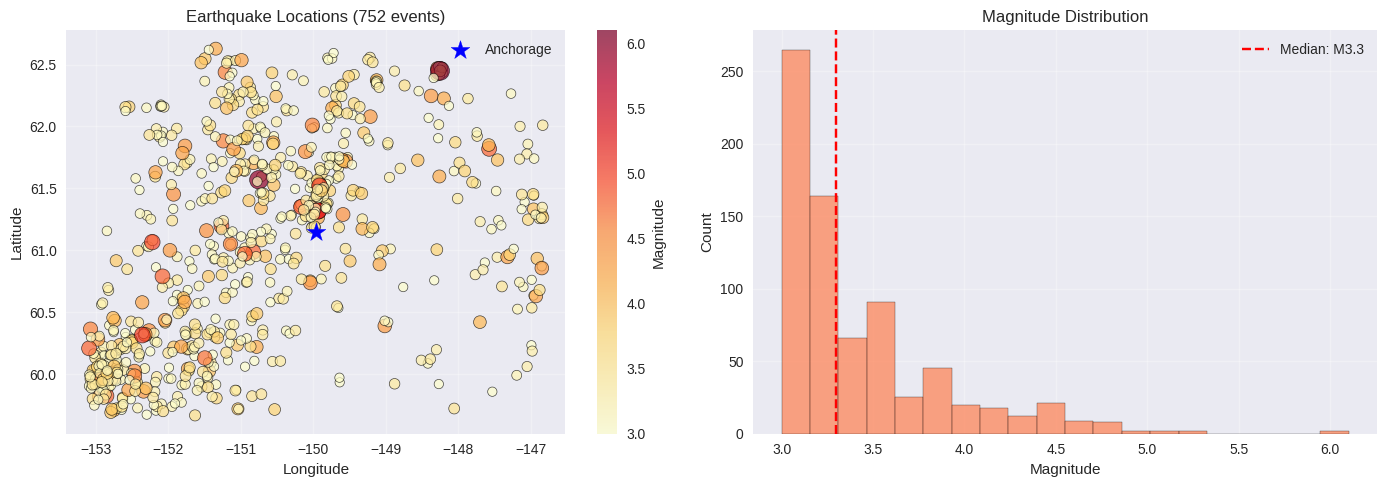

✓ Earthquake visualization complete


In [7]:
# Visualize earthquake locations and magnitudes
if len(events_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Map of earthquakes
    ax1 = axes[0]
    scatter = ax1.scatter(
        events_df['longitude'], 
        events_df['latitude'],
        c=events_df['magnitude'],
        s=events_df['magnitude']**2 * 5,  # Size by magnitude
        cmap='YlOrRd',
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5
    )
    ax1.scatter(REGION['center_lon'], REGION['center_lat'], 
               marker='*', s=200, c='blue', label='Anchorage')
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.set_title(f'Earthquake Locations ({len(events_df)} events)')
    ax1.legend()
    plt.colorbar(scatter, ax=ax1, label='Magnitude')
    ax1.grid(True, alpha=0.3)
    
    # Magnitude histogram
    ax2 = axes[1]
    ax2.hist(events_df['magnitude'], bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax2.set_xlabel('Magnitude')
    ax2.set_ylabel('Count')
    ax2.set_title('Magnitude Distribution')
    ax2.axvline(events_df['magnitude'].median(), color='red', 
                linestyle='--', label=f'Median: M{events_df["magnitude"].median():.1f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Earthquake visualization complete")

## Find AK Network Stations

Get available **Alaska Seismic Network** stations in the region. These are professional-grade seismometers with:

- **Broadband sensors** (typically Guralp, Nanometrics, or Streckeisen)
- **Professional installation** (usually in vaults or boreholes)
- **Better frequency response** (flat from ~0.01 Hz to 50 Hz)
- **Lower noise floor** than Raspberry Shake stations

In [8]:
print("Searching for AK network stations in the region...")

try:
    # Get AK network stations (professional seismic network)
    station_inventory = iris_client.get_stations(
        network="AK",
        minlatitude=REGION['min_lat'] - 0.5,
        maxlatitude=REGION['max_lat'] + 0.5,
        minlongitude=REGION['min_lon'] - 0.5,
        maxlongitude=REGION['max_lon'] + 0.5,
        starttime=UTCDateTime(START_DATE),
        endtime=UTCDateTime(END_DATE),
        channel="BH?,HH?",  # Broadband and High-gain channels
        level="channel"  # Get channel info to see what's available
    )
    
    # Extract station info (deduplicate by station code)
    stations_data = []
    seen_stations = set()
    
    for network in station_inventory:
        for station in network:
            if station.code not in seen_stations:
                # Find available vertical channels (BHZ or HHZ)
                channels = [ch.code for ch in station.channels]
                vertical_channel = None
                if 'BHZ' in channels:
                    vertical_channel = 'BHZ'
                elif 'HHZ' in channels:
                    vertical_channel = 'HHZ'
                
                if vertical_channel:
                    stations_data.append({
                        'network': network.code,
                        'station': station.code,
                        'latitude': station.latitude,
                        'longitude': station.longitude,
                        'elevation': station.elevation,
                        'channel': vertical_channel
                    })
                    seen_stations.add(station.code)
    
    stations_df = pd.DataFrame(stations_data)
    print(f"\n✓ Found {len(stations_df)} AK network stations with broadband channels!")
    
    # Show stations
    print(f"\nAK Network Stations:")
    print(stations_df.to_string(index=False))
    
    # Channel summary
    print(f"\nChannel distribution:")
    print(stations_df['channel'].value_counts().to_string())
    
except Exception as e:
    print(f"Error getting stations: {e}")
    stations_df = pd.DataFrame()

Searching for AK network stations in the region...

✓ Found 3 AK network stations with broadband channels!

AK Network Stations:
network station  latitude  longitude  elevation channel
     AK    FIRE   61.1426  -150.2164       62.0     BHZ
     AK    RC01   61.0889  -149.7390      390.0     BHZ
     AK     SSN   61.4636  -150.7467     1306.0     BHZ

Channel distribution:
channel
BHZ    3


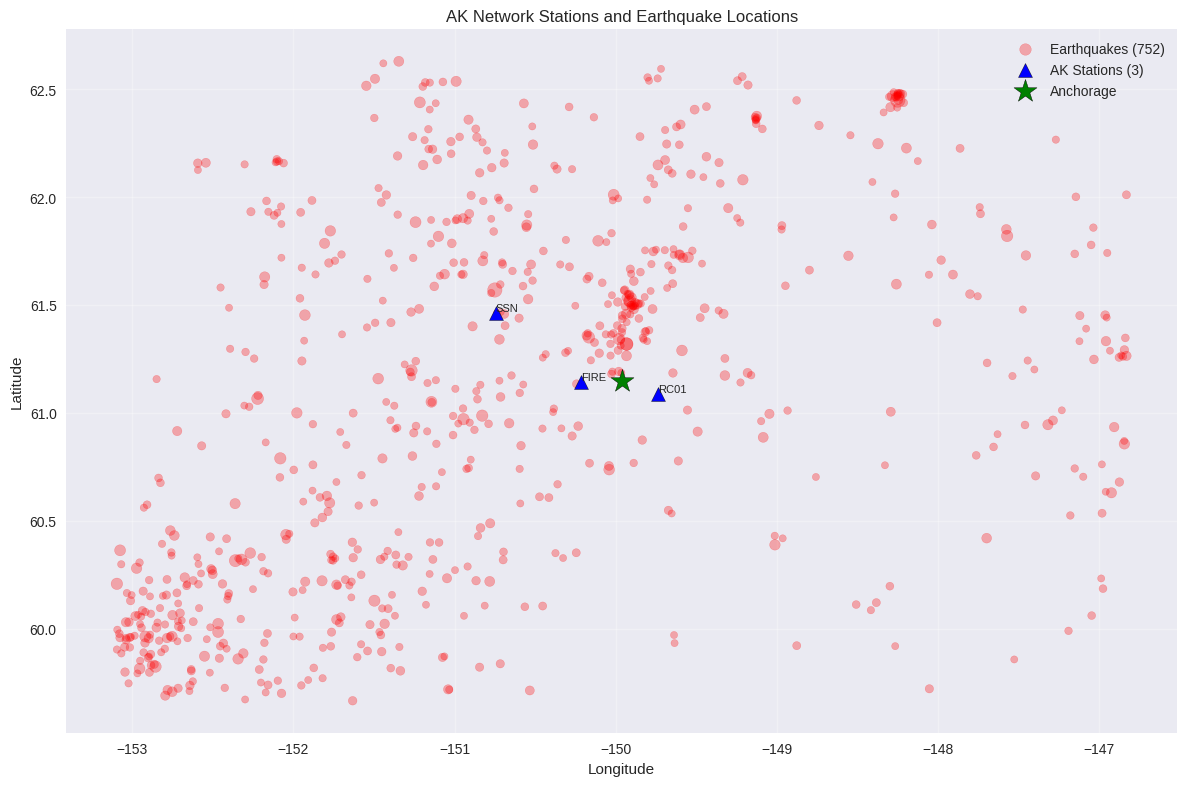

✓ Station/earthquake map complete


In [9]:
# Visualize station locations
if len(stations_df) > 0 and len(events_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot earthquakes
    scatter = ax.scatter(
        events_df['longitude'], 
        events_df['latitude'],
        c='red',
        s=events_df['magnitude']**2 * 3,
        alpha=0.3,
        label=f'Earthquakes ({len(events_df)})',
        marker='o'
    )
    
    # Plot stations
    ax.scatter(
        stations_df['longitude'], 
        stations_df['latitude'],
        c='blue',
        s=100,
        marker='^',
        label=f'AK Stations ({len(stations_df)})',
        edgecolors='black'
    )
    
    # Label stations
    for _, row in stations_df.iterrows():
        ax.annotate(row['station'], (row['longitude'], row['latitude']),
                   fontsize=8, ha='left', va='bottom')
    
    # Plot Anchorage
    ax.scatter(REGION['center_lon'], REGION['center_lat'], 
               marker='*', s=300, c='green', label='Anchorage', edgecolors='black')
    
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('AK Network Stations and Earthquake Locations')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Station/earthquake map complete")

## Download Waveforms for Each Earthquake

For each earthquake, find nearby AK stations and download waveforms. Label windows based on:
- **Earthquake (label=2)**: Windows containing the earthquake signal (after P-wave arrival)
- **Noise (label=0)**: Windows before the earthquake arrives (pre-event noise)

In [10]:
from obspy.signal.trigger import classic_sta_lta, trigger_onset
from libcomcat.search import get_event_by_id
from io import BytesIO

# Helper functions
_comcat_phase_cache = {}  # cache picks per event to avoid redundant HTTP downloads

def calculate_distance(lat1, lon1, lat2, lon2):
    dist_m, _, _ = gps2dist_azimuth(lat1, lon1, lat2, lon2)
    return dist_m / 1000

def get_p_arrival_from_comcat(event_id, station_code, origin_time):
    """
    Fetch P-wave arrival (seconds after origin) from ComCat phase-data QuakeML.
    Caches results per event so all stations for the same event share one download.
    Returns None if no P pick is available for this station.
    """
    if event_id not in _comcat_phase_cache:
        station_picks = {}
        try:
            detail = get_event_by_id(event_id)
            products = detail.getProducts('phase-data')
            if products:
                phase_product = products[0]
                from obspy import read_events
                quakeml_bytes, _ = phase_product.getContentBytes('quakeml.xml')
                cat = read_events(BytesIO(quakeml_bytes))
                if cat:
                    ev = cat[0]
                    origin = ev.preferred_origin() or (ev.origins[0] if ev.origins else None)
                    pid2pick = {str(p.resource_id): p for p in ev.picks}
                    # Preferred: phase label lives on origin arrivals (older AEC events)
                    if origin is not None:
                        for arr in origin.arrivals:
                            if not (arr.phase or '').upper().startswith('P'):
                                continue
                            pick = pid2pick.get(str(arr.pick_id))
                            if pick is not None:
                                sta = pick.waveform_id.station_code.upper()
                                station_picks.setdefault(sta, pick.time)
                    # Fallback: phase_hint on picks (events without arrival phases)
                    for pick in ev.picks:
                        sta = pick.waveform_id.station_code.upper()
                        if (pick.phase_hint or '').upper().startswith('P'):
                            station_picks.setdefault(sta, pick.time)
        except Exception as e:
            print(f"      [comcat ERROR] {event_id}: {type(e).__name__}: {str(e)[:120]}")
        _comcat_phase_cache[event_id] = station_picks

    pick_time = _comcat_phase_cache[event_id].get(station_code.upper())
    if pick_time is None:
        return None
    p_sec = float(pick_time - origin_time)
    return p_sec if 0 < p_sec < 300 else None

def find_nearby_stations(event_lat, event_lon, stations_df, max_distance_km):
    distances = [
        calculate_distance(event_lat, event_lon, row['latitude'], row['longitude'])
        for _, row in stations_df.iterrows()
    ]
    result_df = stations_df.copy()
    result_df['distance_km'] = distances
    nearby = result_df[result_df['distance_km'] <= max_distance_km]
    return nearby.sort_values('distance_km')

print("✓ Helper functions defined")
print("  - get_p_arrival_from_comcat: ComCat phase-data QuakeML picks (AK stations, cached per event)")
print("  - find_p_arrival_stalta:     STA/LTA trigger (Raspberry Shake stations)")


✓ Helper functions defined
  - get_p_arrival_from_comcat: ComCat phase-data QuakeML picks (AK stations, cached per event)
  - find_p_arrival_stalta:     STA/LTA trigger (Raspberry Shake stations)


In [11]:
# Main data collection loop
print("=" * 80)
print("DOWNLOADING AK NETWORK EARTHQUAKE WAVEFORMS")
print("=" * 80)

# Storage for all windows
all_windows = []
all_labels = []
all_metadata = []

# Windowing parameters (random-shift CNN scheme)
# EQ window = [P-30s, P+90s] = 120 s, with P sitting 30 s in so the clip can be
# randomly shifted at train time. Noise window = [P-90s, P-30s] = 60 s of pre-event noise.
EQ_PRE_SEC    = 30.0
EQ_POST_SEC   = 90.0
NOISE_PRE_SEC = 90.0   # noise starts 90 s before P
NOISE_END_SEC = 30.0   # noise ends 30 s before P

eq_pre_samples    = int(EQ_PRE_SEC * SAMPLING_RATE)      # 3000
eq_post_samples   = int(EQ_POST_SEC * SAMPLING_RATE)     # 9000
eq_samples        = eq_pre_samples + eq_post_samples     # 12000 (120 s)
noise_pre_samples = int(NOISE_PRE_SEC * SAMPLING_RATE)   # 9000 (start, before P)
noise_end_samples = int(NOISE_END_SEC * SAMPLING_RATE)   # 3000 (end, before P)
noise_samples     = noise_pre_samples - noise_end_samples  # 6000 (60 s)

# Track statistics
successful_downloads = 0
failed_downloads = 0
total_earthquake_windows = 0
total_noise_windows = 0

# Class names for reference
class_names = {0: 'Noise', 1: 'Traffic', 2: 'Earthquake'}

n_events = min(MAX_EVENTS, len(catalog))
print(f"\nProcessing {n_events} earthquakes...")
print(f"EQ window:    {eq_samples} samples  ([P-{EQ_PRE_SEC:.0f}s, P+{EQ_POST_SEC:.0f}s] = {eq_samples/SAMPLING_RATE:.0f}s)")
print(f"Noise window: {noise_samples} samples  ([P-{NOISE_PRE_SEC:.0f}s, P-{NOISE_END_SEC:.0f}s] = {noise_samples/SAMPLING_RATE:.0f}s)")
print(f"AK stations: P-arrival from ComCat phase-data QuakeML picks")
print(f"")
print("-" * 80)

for event_idx, event in enumerate(catalog[:n_events]):
    # Get event info
    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]
    event_time = origin.time
    event_lat = origin.latitude
    event_lon = origin.longitude
    event_depth = origin.depth / 1000 if origin.depth else 10  # km
    _rid = str(event.resource_id)
    if 'eventid=' in _rid:
        event_id = _rid.split('eventid=')[1].split('&')[0]
    else:
        event_id = _rid.split('/')[-1].replace('.quakeml', '')

    print(f"\n[{event_idx+1}/{n_events}] M{magnitude.mag:.1f} at {event_time.strftime('%Y-%m-%d %H:%M:%S')}")

    # Find nearby stations
    nearby_stations = find_nearby_stations(event_lat, event_lon, stations_df, MAX_STATION_DISTANCE_KM)

    if len(nearby_stations) == 0:
        print(f"  ⚠ No stations within {MAX_STATION_DISTANCE_KM} km")
        continue

    print(f"  Found {len(nearby_stations)} nearby stations")

    # Get RC01 P-arrival as reference for validating AM STA/LTA triggers.
    rc01_p_sec = None
    rc01_dist_km = None
    rc01_row = nearby_stations[nearby_stations['station'] == 'RC01']
    if len(rc01_row) > 0:
        rc01_p_sec = get_p_arrival_from_comcat(event_id, 'RC01', event_time)
        if rc01_p_sec is not None:
            rc01_dist_km = float(rc01_row.iloc[0]['distance_km'])

    # Try downloading from nearest stations
    stations_succeeded = 0
    n_no_pick = 0
    n_fdsn_err = 0

    for _, station_info in nearby_stations.head(MAX_STATIONS_PER_EVENT).iterrows():
        station_code = station_info['station']
        distance_km = station_info['distance_km']
        channel = station_info['channel']  # BHZ or HHZ

        station_network = station_info['network']
        if station_network == 'AM':
            continue  # AM disabled — AK-only run

        # AK network: require a ComCat validated pick
        p_arrival_sec = get_p_arrival_from_comcat(event_id, station_code, event_time)
        if p_arrival_sec is None:
            failed_downloads += 1
            n_no_pick += 1
            continue  # No validated phase data — skip

        # Download window must cover noise start (P-90s) through EQ end (P+90s),
        # plus a few seconds of buffer for taper/filter edge effects.
        p_time = event_time + p_arrival_sec
        download_start = p_time - NOISE_PRE_SEC - 10
        download_end   = p_time + EQ_POST_SEC + 10

        try:
            fdsn_client = raspishake_client if station_network == 'AM' else iris_client
            stream = fdsn_client.get_waveforms(
                network=station_network,
                station=station_code,
                location="*",
                channel=channel,
                starttime=download_start,
                endtime=download_end
            )

            if len(stream) == 0:
                continue

            stream.merge(method=1, fill_value='interpolate')

            stream.detrend('linear')
            stream.detrend('demean')
            stream.taper(max_percentage=0.05)
            stream.filter('bandpass', freqmin=2, freqmax=20, corners=4)
            if stream[0].stats.sampling_rate != SAMPLING_RATE:
                stream.resample(SAMPLING_RATE)

            trace = stream[0]
            data = trace.data
            trace_start = trace.stats.starttime

            p_arrival_sample = int((event_time + p_arrival_sec - trace_start) * SAMPLING_RATE)

            n_samples = len(data)
            event_windows = 0
            noise_windows = 0

            # EARTHQUAKE WINDOW: [P-30s, P+90s] = 120 s. P sits 30 s into the window,
            # leaving slack for random temporal shifting at CNN train time.
            eq_win_start = p_arrival_sample - eq_pre_samples
            eq_win_end   = p_arrival_sample + eq_post_samples

            if eq_win_start >= 0 and eq_win_end <= n_samples:
                eq_window = data[eq_win_start:eq_win_end]

                if len(eq_window) == eq_samples and np.std(eq_window) > 1e-10:
                    eq_window_norm = (eq_window - np.mean(eq_window)) / (np.std(eq_window) + 1e-10)

                    all_windows.append(eq_window_norm)
                    all_labels.append(2)  # Earthquake
                    event_windows += 1

                    all_metadata.append({
                        'event_id': event_id,
                        'event_time': str(event_time),
                        'magnitude': magnitude.mag,
                        'event_lat': event_lat,
                        'event_lon': event_lon,
                        'event_depth_km': event_depth,
                        'network': station_network,
                        'station': station_code,
                        'channel': channel,
                        'distance_km': distance_km,
                        'p_arrival_sec': p_arrival_sec,
                        'p_arrival_source': 'rc01_extrap' if station_network == 'AM' else 'comcat',
                        'window_start_sec': eq_win_start / SAMPLING_RATE,
                        'window_len_sec': eq_samples / SAMPLING_RATE,
                        'p_offset_sec': EQ_PRE_SEC,   # P is this many seconds into the window
                        'window_type': 'earthquake',
                        'label': 2,
                        'label_name': 'Earthquake'
                    })

            # NOISE WINDOW: [P-90s, P-30s] = 60 s of pre-event noise (ends 30 s before P).
            noise_win_start = p_arrival_sample - noise_pre_samples
            noise_win_end   = p_arrival_sample - noise_end_samples

            if noise_win_start >= 0 and noise_win_end <= n_samples:
                noise_window = data[noise_win_start:noise_win_end]

                if len(noise_window) == noise_samples and np.std(noise_window) > 1e-10:
                    noise_window_norm = (noise_window - np.mean(noise_window)) / (np.std(noise_window) + 1e-10)

                    all_windows.append(noise_window_norm)
                    all_labels.append(0)  # Noise
                    noise_windows += 1

                    all_metadata.append({
                        'event_id': event_id,
                        'event_time': str(event_time),
                        'magnitude': magnitude.mag,
                        'event_lat': event_lat,
                        'event_lon': event_lon,
                        'event_depth_km': event_depth,
                        'network': station_network,
                        'station': station_code,
                        'channel': channel,
                        'distance_km': distance_km,
                        'p_arrival_sec': p_arrival_sec,
                        'p_arrival_source': 'rc01_extrap' if station_network == 'AM' else 'comcat',
                        'window_start_sec': noise_win_start / SAMPLING_RATE,
                        'window_len_sec': noise_samples / SAMPLING_RATE,
                        'p_offset_sec': None,
                        'window_type': 'noise',
                        'label': 0,
                        'label_name': 'Noise'
                    })

            total_earthquake_windows += event_windows
            total_noise_windows += noise_windows
            stations_succeeded += 1
            successful_downloads += 1

            print(f"    ✓ {station_code}.{channel} ({distance_km:.1f} km): {event_windows} EQ + {noise_windows} noise windows")

        except Exception as e:
            failed_downloads += 1
            n_fdsn_err += 1
            print(f"    ✗ {station_code} FDSN: {type(e).__name__}: {str(e)[:80]}")
            pass

        # Small delay to avoid overwhelming the server
        time.sleep(0.2)

    if stations_succeeded == 0:
        print(f"  ⚠ No data from any station (no comcat pick: {n_no_pick}, FDSN errors: {n_fdsn_err})")

print("\n" + "=" * 80)
print("EARTHQUAKE WINDOWS DOWNLOAD COMPLETE")
print("=" * 80)
print(f"\nEarthquake Statistics:")
print(f"  Successful downloads: {successful_downloads}")
print(f"  Failed downloads: {failed_downloads}")
print(f"  Total earthquake windows: {total_earthquake_windows}")
print(f"  Total noise windows: {total_noise_windows}")
print(f"  Total windows so far: {len(all_windows)}")

DOWNLOADING AK NETWORK EARTHQUAKE WAVEFORMS

Processing 700 earthquakes...
EQ window:    12000 samples  ([P-30s, P+90s] = 120s)
Noise window: 6000 samples  ([P-90s, P-30s] = 60s)
AK stations: P-arrival from ComCat phase-data QuakeML picks

--------------------------------------------------------------------------------

[1/700] M3.0 at 2025-11-29 13:56:09
  Found 2 nearby stations
    ✓ RC01.BHZ (134.4 km): 1 EQ + 1 noise windows

[2/700] M3.2 at 2025-11-28 17:32:32
  Found 3 nearby stations
    ✓ SSN.BHZ (14.7 km): 1 EQ + 1 noise windows
    ✓ FIRE.BHZ (57.1 km): 1 EQ + 1 noise windows
    ✓ RC01.BHZ (76.9 km): 1 EQ + 1 noise windows

[3/700] M3.3 at 2025-11-28 05:26:09
  Found 2 nearby stations
  ⚠ No data from any station (no comcat pick: 2, FDSN errors: 0)

[4/700] M3.1 at 2025-11-28 02:38:54
  Found 2 nearby stations
    ✓ FIRE.BHZ (134.2 km): 1 EQ + 1 noise windows

[5/700] M3.2 at 2025-11-27 17:41:13
  Found 3 nearby stations
    ✓ RC01.BHZ (71.7 km): 1 EQ + 1 noise windows

[6/

In [12]:
# ── Window review — browse collected windows ─────────────────────────────────
# SOURCE: 'comcat'/'rc01_extrap'/None.  LABEL: 2=EQ, 0=Noise, None=both.
# Windows are variable length now (EQ 120 s, noise 60 s) so we index the list
# directly and build a per-window time axis.
SOURCE  = 'comcat'
LABEL   = 0
PAGE    = 4
PER_ROW = 5
ROWS    = 100

metadata_df = pd.DataFrame(all_metadata)
y = np.array(all_labels)

mask = np.ones(len(all_windows), dtype=bool)
if SOURCE is not None:
    mask &= metadata_df['p_arrival_source'].values == SOURCE
if LABEL is not None:
    mask &= y == LABEL
idx = np.where(mask)[0]

start = PAGE * PER_ROW * ROWS
batch = idx[start : start + PER_ROW * ROWS]

if len(batch) == 0:
    print(f"No windows matching SOURCE={SOURCE!r}, LABEL={LABEL} on PAGE={PAGE}")
else:
    fig, axes = plt.subplots(ROWS, PER_ROW, figsize=(PER_ROW * 4, ROWS * 2.5), squeeze=False)
    for ax_idx, win_idx in enumerate(batch):
        ax = axes[ax_idx // PER_ROW][ax_idx % PER_ROW]
        win  = all_windows[win_idx]
        meta = metadata_df.iloc[win_idx]
        tt   = np.arange(len(win)) / SAMPLING_RATE          # seconds from window start
        ax.plot(tt, win, lw=0.6, color='steelblue' if y[win_idx]==2 else 'gray')
        p_off = meta.get('p_offset_sec')
        if p_off is not None and not pd.isna(p_off):
            ax.axvline(p_off, color='red', lw=0.8, alpha=0.6)   # P-arrival
        ax.set_title(
            f"[{win_idx}] {meta['label_name']} | {meta['station']} | M{meta['magnitude']:.1f} | {meta['distance_km']:.0f}km\n"
            f"{meta['p_arrival_source']} | {meta['event_time'][:10]}  ({len(win)/SAMPLING_RATE:.0f}s)",
            fontsize=7
        )
        ax.set_xlabel('s from window start', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.2)
    for ax_idx in range(len(batch), ROWS * PER_ROW):
        axes[ax_idx // PER_ROW][ax_idx % PER_ROW].set_visible(False)

    plt.suptitle(
        f"SOURCE={SOURCE!r}  LABEL={'EQ' if LABEL==2 else 'Noise' if LABEL==0 else 'all'}"
        f"  |  showing {start+1}-{start+len(batch)} of {len(idx)} windows  (PAGE={PAGE})",
        fontsize=9
    )
    plt.tight_layout()
    plt.show()
    print(f"Showing {len(batch)} windows. Increment PAGE to see more.")


No windows matching SOURCE='comcat', LABEL=0 on PAGE=4


In [13]:
# ── Curation step 1: remove bad windows by index ─────────────────────────────
# After reviewing (cells above), list the indexes of windows you want to drop.
# Indexes refer to the CURRENT ordering of all_windows. Run this once; after it
# runs the remaining windows are renumbered 0..N-1, so re-review before removing again.
BAD_INDICES = [3, 15, 59, 61, 77, 87, 133, 169, 173, 181, 201, 205, 217, 225, 239, 253, 279,
               287, 293, 323, 331, 339, 347, 351, 355, 379, 381, 387, 401, 405, 559, 571, 591,
               635, 641, 685, 687, 691, 743, 781, 783, 795, 847, 861, 911, 929, 937, 955, 965, 973, 977, 991,
               993, 1017, 1037, 1039, 1045, 1065, 1075, 1087, 1133, 1139, 1169, 1197, 1209, 1219, 1221, 1257,
               1275, 1293, 1351, 1535, 1355, 1359, 1435, 1467, 1543, 1545, 1675, 1713, 1725, 1729, 1765, 1795,
               1847, 1849, 1853, 1925, 1829, 1931, 1935, 1937, 1943, 1965, 1997, 2007, 2039, 2045]   # e.g. [3, 17, 42]

def remove_windows(bad_indices):
    """Drop the given indexes from all_windows/all_labels/all_metadata/all_post_windows
    together so the four lists stay aligned."""
    bad  = {int(i) for i in bad_indices}
    keep = [i for i in range(len(all_windows)) if i not in bad]
    n_removed = len(all_windows) - len(keep)
    all_windows[:]      = [all_windows[i]      for i in keep]
    all_labels[:]       = [all_labels[i]       for i in keep]
    all_metadata[:]     = [all_metadata[i]     for i in keep]
    print(f"Removed {n_removed} windows; {len(all_windows)} remain.")

remove_windows(BAD_INDICES)


Removed 98 windows; 1950 remain.


## Noise Windows (collected in main loop)

Noise windows are extracted from the **60 seconds immediately before the P-wave arrival** within each earthquake download. No separate download step is needed.

In [14]:
# Noise windows were already collected in the main loop above (pre-P-arrival windows).
# Print a summary of what was gathered.

print('=' * 80)
print('DATASET STATISTICS')
print('=' * 80)
print(f'  Total earthquake windows: {total_earthquake_windows}')
print(f'  Total noise windows (pre-P-arrival): {total_noise_windows}')
print(f'  Total windows: {len(all_windows)}')
if all_labels:
    unique, counts = np.unique(all_labels, return_counts=True)
    print(f'  Class distribution:')
    for label, count in zip(unique, counts):
        print(f'    {class_names[label]}: {count} ({count/len(all_labels)*100:.1f}%)')


DATASET STATISTICS
  Total earthquake windows: 1024
  Total noise windows (pre-P-arrival): 1024
  Total windows: 1950
  Class distribution:
    Noise: 926 (47.5%)
    Earthquake: 1024 (52.5%)


## Visualize Downloaded Data

In [15]:
# Convert to arrays / dataset summary.
# EQ (120 s) and noise (60 s) have different lengths, so keep them as separate
# rectangular arrays rather than one ragged array.
if len(all_windows) > 0:
    y = np.array(all_labels)
    metadata_df = pd.DataFrame(all_metadata)

    eq_idx    = [i for i in range(len(all_windows)) if all_labels[i] == 2]
    noise_idx = [i for i in range(len(all_windows)) if all_labels[i] == 0]
    X_eq    = np.array([all_windows[i] for i in eq_idx])    if eq_idx    else np.empty((0, 0))
    X_noise = np.array([all_windows[i] for i in noise_idx]) if noise_idx else np.empty((0, 0))

    print(f"Earthquake windows: X_eq={X_eq.shape}")
    print(f"Noise windows:      X_noise={X_noise.shape}")
    print(f"Total windows: {len(all_windows)}")

    unique, counts = np.unique(y, return_counts=True)
    print(f"\nClass distribution:")
    for label, count in zip(unique, counts):
        print(f"  {class_names[label]}: {count} ({count/len(y)*100:.1f}%)")

    print(f"\nData diversity:")
    print(f"  Unique earthquakes: {metadata_df['event_id'].nunique()}")
    print(f"  Unique stations: {metadata_df['station'].nunique()}")
    print(f"  Channels used: {metadata_df['channel'].unique().tolist()}")
    print(f"  Magnitude range: M{metadata_df['magnitude'].min():.1f} - M{metadata_df['magnitude'].max():.1f}")
    print(f"  Distance range: {metadata_df['distance_km'].min():.1f} - {metadata_df['distance_km'].max():.1f} km")
else:
    print("No data collected. Check earthquake catalog and station availability.")


Earthquake windows: X_eq=(1024, 12000)
Noise windows:      X_noise=(926, 6000)
Total windows: 1950

Class distribution:
  Noise: 926 (47.5%)
  Earthquake: 1024 (52.5%)

Data diversity:
  Unique earthquakes: 477
  Unique stations: 3
  Channels used: ['BHZ']
  Magnitude range: M3.0 - M6.0
  Distance range: 1.7 - 149.9 km


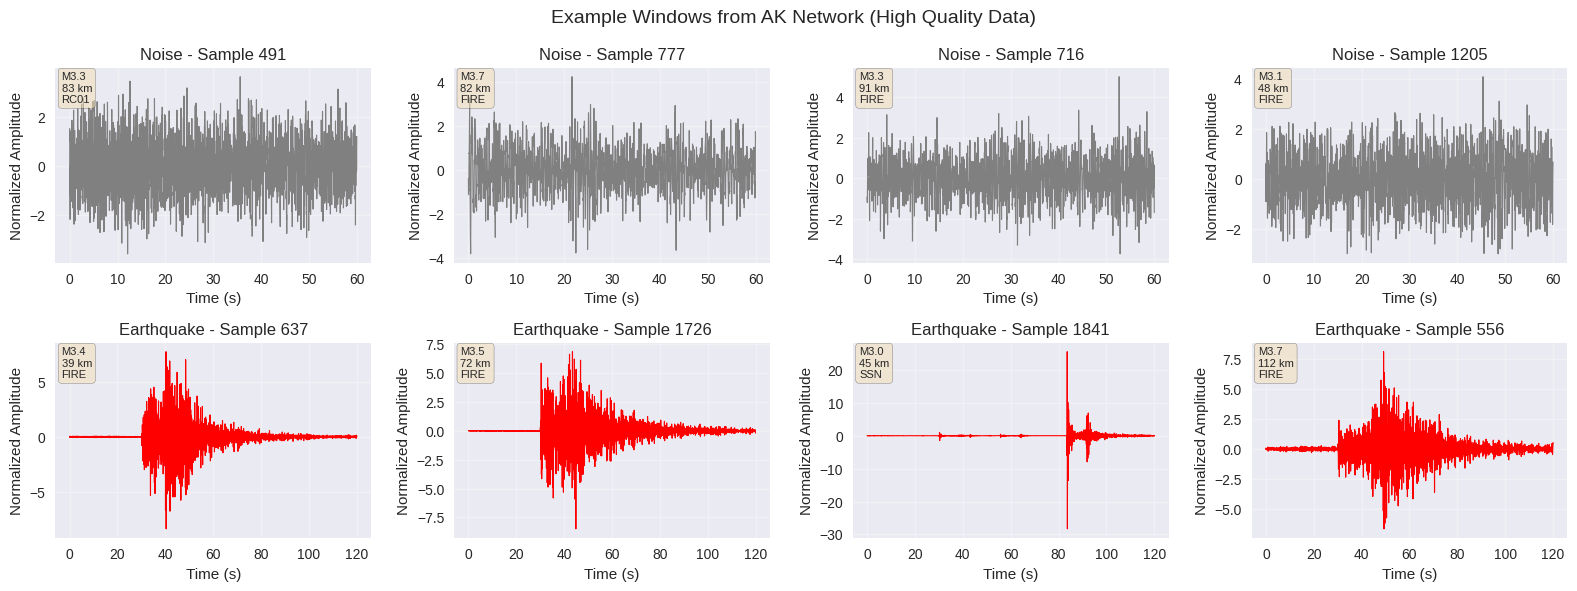

✓ Example windows visualized


In [16]:
# Visualize example windows from each class
if len(all_windows) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))

    for row, (indices, class_label, color) in enumerate([
        (noise_idx, 0, 'gray'),   # row 0: noise
        (eq_idx,    2, 'red'),    # row 1: earthquake
    ]):
        class_name = class_names[class_label]
        if len(indices) == 0:
            continue

        n_examples = min(4, len(indices))
        example_indices = np.random.choice(indices, n_examples, replace=False)

        for col, idx in enumerate(example_indices):
            window = all_windows[idx]
            time_axis = np.arange(len(window)) / SAMPLING_RATE
            ax = axes[row, col]
            ax.plot(time_axis, window, linewidth=0.8, color=color)
            ax.set_title(f"{class_name} - Sample {idx}")
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Normalized Amplitude')
            ax.grid(True, alpha=0.3)

            meta = metadata_df.iloc[idx]
            ax.text(0.02, 0.98, f"M{meta['magnitude']:.1f}\n{meta['distance_km']:.0f} km\n{meta['station']}",
                   transform=ax.transAxes, fontsize=8, va='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('Example Windows from AK Network (High Quality Data)', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("✓ Example windows visualized")

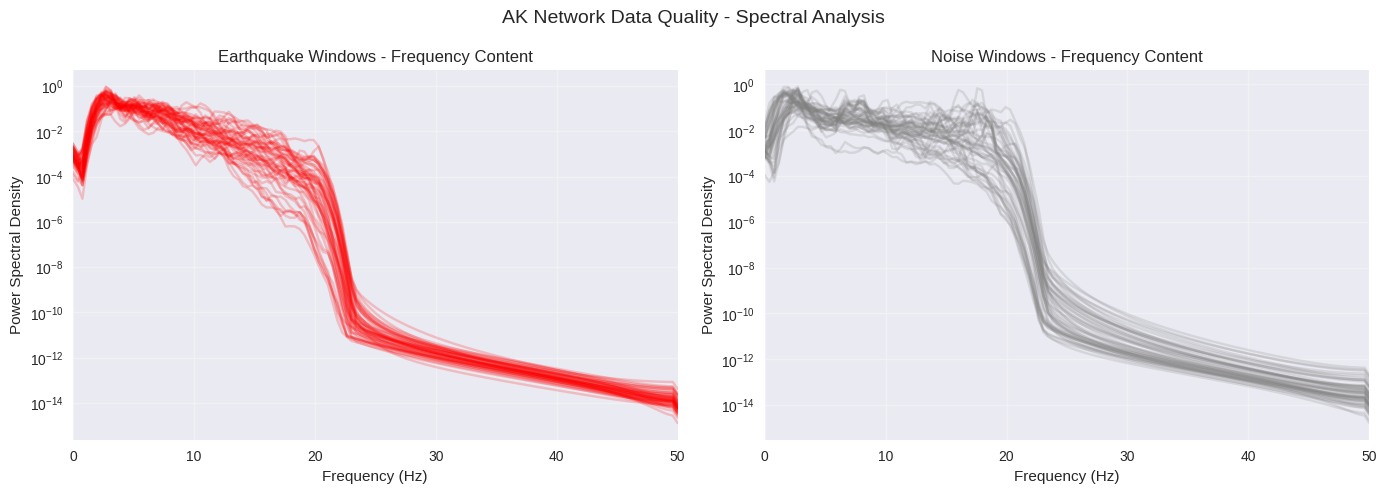

✓ Spectral analysis complete


In [17]:
# Compare signal quality - spectral analysis
if len(all_windows) > 0:
    from scipy import signal as scipy_signal
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, indices, color, title in [
        (axes[0], eq_idx,    'red',  'Earthquake Windows - Frequency Content'),
        (axes[1], noise_idx, 'gray', 'Noise Windows - Frequency Content'),
    ]:
        n_samples = min(50, len(indices))
        if n_samples > 0:
            sample_idx = np.random.choice(indices, n_samples, replace=False)
            for idx in sample_idx:
                freqs, psd = scipy_signal.welch(all_windows[idx], fs=SAMPLING_RATE, nperseg=256)
                ax.semilogy(freqs, psd, alpha=0.2, color=color)

        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Power Spectral Density')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 50])

    plt.suptitle('AK Network Data Quality - Spectral Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("✓ Spectral analysis complete")

## Save the Dataset

In [18]:
if len(all_windows) > 0:
    from tqdm.auto import tqdm
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Three-file format (waveforms / labels / metadata), keeping the ragged
    # random-shift windows: EQ = 12000 samples ([P-30s, P+90s], P at sample
    # 3000), noise = 6000 samples ([P-90s, P-30s]). The waveforms file is an
    # object array of per-window float32 arrays (ragged), so it must be
    # loaded with allow_pickle=True.
    X_out = np.empty(len(all_windows), dtype=object)
    for i, w in enumerate(tqdm(all_windows, desc="Packing windows")):
        X_out[i] = np.asarray(w, dtype=np.float32)
    y = np.array(all_labels)
    metadata_df = pd.DataFrame(all_metadata)

    waveforms_file = OUTPUT_DIR / f"AK_waveforms_{timestamp}.npy"
    np.save(waveforms_file, X_out, allow_pickle=True)
    labels_file = OUTPUT_DIR / f"AK_labels_{timestamp}.npy"
    np.save(labels_file, y)
    metadata_file = OUTPUT_DIR / f"AK_metadata_{timestamp}.csv"
    metadata_df.to_csv(metadata_file, index=False)

    print(f"✓ Saved {len(X_out)} windows to: {waveforms_file}")
    print(f"    EQ: {(y == 2).sum()} (12000 samples)  |  Noise: {(y == 0).sum()} (6000 samples)")
    print(f"✓ Saved labels to:   {labels_file}")
    print(f"✓ Saved metadata to: {metadata_file}  ({len(metadata_df)} rows)")

    print("\n" + "=" * 60)
    print("AK NETWORK DATASET SAVED SUCCESSFULLY!")
    print("=" * 60)
    print(f"\nWindowing (random-shift CNN scheme):")
    print(f"  EQ window:    [P-{EQ_PRE_SEC:.0f}s, P+{EQ_POST_SEC:.0f}s]  ({eq_samples} samples, P at {EQ_PRE_SEC:.0f}s)")
    print(f"  Noise window: [P-{NOISE_PRE_SEC:.0f}s, P-{NOISE_END_SEC:.0f}s]  ({noise_samples} samples)")
    print(f"  Unique events: {metadata_df['event_id'].nunique()}, "
          f"stations: {metadata_df['station'].nunique()}")
    print(f"\nTo load for training:")
    print(f"  X = np.load('{waveforms_file}', allow_pickle=True)  # object array of ragged windows")
    print(f"  y = np.load('{labels_file}')")
    print(f"  metadata = pd.read_csv('{metadata_file}')")
else:
    print("No data to save.")

Packing windows: 100%|██████████| 1950/1950 [00:00<00:00, 45412.06it/s]

✓ Saved 1950 windows to: labeled_data/AK_waveforms_20260709_093933.npy
    EQ: 1024 (12000 samples)  |  Noise: 926 (6000 samples)
✓ Saved labels to:   labeled_data/AK_labels_20260709_093933.npy
✓ Saved metadata to: labeled_data/AK_metadata_20260709_093933.csv  (1950 rows)

AK NETWORK DATASET SAVED SUCCESSFULLY!

Windowing (random-shift CNN scheme):
  EQ window:    [P-30s, P+90s]  (12000 samples, P at 30s)
  Noise window: [P-90s, P-30s]  (6000 samples)
  Unique events: 477, stations: 3

To load for training:
  X = np.load('labeled_data/AK_waveforms_20260709_093933.npy', allow_pickle=True)  # object array of ragged windows
  y = np.load('labeled_data/AK_labels_20260709_093933.npy')
  metadata = pd.read_csv('labeled_data/AK_metadata_20260709_093933.csv')


## Additional Save: SeisBench-Compatible Dataset

Writes the same curated windows as a standard SeisBench dataset (`metadata.csv` + `waveforms.hdf5`) with event-level train/dev/test splits. Loadable via `seisbench.data.WaveformDataset`.

In [19]:
# ── Additional save: SeisBench-compatible dataset ────────────────────────────
# Writes labeled_data/AK_seisbench_<timestamp>/{metadata.csv, waveforms.hdf5}
# using SeisBench column conventions (source_*/station_*/trace_*/path_*).
# One trace per window: EQ windows carry trace_p_arrival_sample (P at 30 s),
# noise windows have no pick. Ragged lengths (12000/6000) are fine — the
# writer buckets them; train-time windows are still 6000 samples (RandomWindow).
# Splits are assigned per EVENT (hash of event_id) so no earthquake straddles
# train/dev/test across stations.
#
# NOTE: these traces are the processed windows (bandpass 2-20 Hz, per-window
# z-normalized, Z only) — good for training your own models via seisbench,
# not directly comparable to pretrained 3-C pickers.
from seisbench.data import WaveformDataWriter
from tqdm.auto import tqdm
import hashlib

def event_split(event_id, train_pct=70, dev_pct=15):
    """Deterministic train/dev/test assignment, constant per event."""
    h = int(hashlib.md5(str(event_id).encode()).hexdigest(), 16) % 100
    if h < train_pct:
        return 'train'
    return 'dev' if h < train_pct + dev_pct else 'test'

if len(all_windows) > 0:
    sb_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    sb_dir = OUTPUT_DIR / f"AK_seisbench_{sb_timestamp}"
    sb_dir.mkdir(exist_ok=True)

    with WaveformDataWriter(sb_dir / "metadata.csv", sb_dir / "waveforms.hdf5") as writer:
        writer.data_format = {
            "dimension_order": "CW",
            "component_order": "Z",
            "sampling_rate": SAMPLING_RATE,
            "measurement": "velocity",
            "unit": "normalized",          # per-window z-normalized, bandpassed 2-20 Hz
            "instrument_response": "not restituted",
        }

        for w, lbl, meta in tqdm(zip(all_windows, all_labels, all_metadata),
                                 total=len(all_windows), desc="Writing SeisBench traces"):
            row = {
                "source_id": meta["event_id"],
                "source_origin_time": meta["event_time"],
                "source_magnitude": meta["magnitude"],
                "source_latitude": meta["event_lat"],
                "source_longitude": meta["event_lon"],
                "source_depth_km": meta["event_depth_km"],
                "station_network_code": meta["network"],
                "station_code": meta["station"],
                "trace_channel": meta["channel"],
                "trace_sampling_rate_hz": SAMPLING_RATE,
                "path_ep_distance_km": meta["distance_km"],
                "trace_category": meta["window_type"],       # 'earthquake' / 'noise'
                "trace_p_arrival_source": meta["p_arrival_source"],
                "split": event_split(meta["event_id"]),
            }
            p_off = meta.get("p_offset_sec")
            if p_off is not None:
                row["trace_p_arrival_sample"] = int(p_off * SAMPLING_RATE)
            writer.add_trace(row, np.asarray(w, dtype=np.float32)[np.newaxis, :])

    sb_meta = pd.read_csv(sb_dir / "metadata.csv")
    print(f"\n✓ SeisBench dataset written to: {sb_dir}/")
    print(f"    {len(sb_meta)} traces "
          f"({(sb_meta['trace_category'] == 'earthquake').sum()} EQ, "
          f"{(sb_meta['trace_category'] == 'noise').sum()} noise)")
    print(f"    Splits: {sb_meta['split'].value_counts().to_dict()}")
    print(f"\nTo load:")
    print(f"  import seisbench.data as sbd")
    print(f"  data = sbd.WaveformDataset(r'{sb_dir}')")
    print(f"  train, dev, test = data.train(), data.dev(), data.test()")
else:
    print("No data to save.")


Writing SeisBench traces: 100%|██████████| 1950/1950 [00:00<00:00, 21987.10it/s]
Traces converted: 1950it [00:00, 9163.14it/s]


✓ SeisBench dataset written to: labeled_data/AK_seisbench_20260709_093935/
    1950 traces (1024 EQ, 926 noise)
    Splits: {'train': 1386, 'test': 289, 'dev': 275}

To load:
  import seisbench.data as sbd
  data = sbd.WaveformDataset(r'labeled_data/AK_seisbench_20260709_093935')
  train, dev, test = data.train(), data.dev(), data.test()


## Next Steps

Now that you have high-quality AK network earthquake data:

1. **Train the model**: Use `notebooks/03_training/train_cnn_multiclass.ipynb` with this dataset
2. **Compare results**: Compare accuracy between:
   - AM (Raspberry Shake) data - citizen science, lower quality
   - AK network data - professional, higher quality
3. **Expand dataset**: Increase `MAX_EVENTS` or extend date range for more data
4. **Combine datasets**: Could potentially use both AM and AK data for training

### Expected Improvements

AK network data should provide:
- **Cleaner signals**: Better signal-to-noise ratio
- **More consistent data**: Professional installation means less variability
- **Better frequency response**: Broadband sensors capture more of the earthquake signal
- **Higher accuracy**: Cleaner training data → better model performance

In [21]:
print("\n🎉 AK Network Notebook complete!")
print("\nDataset summary:")
if len(all_windows) > 0:
    print(f"  • {len(all_windows)} total windows")
    print(f"  • {(y == 2).sum()} earthquake windows")
    print(f"  • {(y == 0).sum()} noise windows")
    print(f"  • From {metadata_df['event_id'].nunique()} unique earthquakes")
    print(f"  • Recorded at {metadata_df['station'].nunique()} AK network stations")
    print(f"\n  Network: AK (Alaska Seismic Network - HIGH QUALITY)")
else:
    print("  No data collected - check configuration and try again.")


🎉 AK Network Notebook complete!

Dataset summary:
  • 1950 total windows
  • 1024 earthquake windows
  • 926 noise windows
  • From 477 unique earthquakes
  • Recorded at 3 AK network stations

  Network: AK (Alaska Seismic Network - HIGH QUALITY)
